In [1]:
# Import dependencies

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, precision_recall_fscore_support

2025-11-12 15:20:40.205205: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762960840.453501      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762960840.524750      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# Paths

root = "/kaggle/input/breast-cancer-detection-mri/Breast_Cancer_MRI_Dataset"
IMG_SIZE = (512, 512)
BATCH = 16
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [3]:
# Load dataset


def build_ds(subdir, augment=False, shuffle=False):
    ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(root, subdir),
        labels="inferred",
        label_mode="int",
        color_mode="rgb",
        batch_size=BATCH,
        image_size=IMG_SIZE,
        shuffle=shuffle,
        seed=SEED
    )

    aug = keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.05),
        layers.RandomContrast(0.1),
        layers.RandomZoom(0.1)
    ]) if augment else None

    def _map(x, y):
        x = tf.cast(x, tf.float32)
        if aug is not None:
            x = aug(x, training=True)
        return x, y

    return (ds.map(_map, num_parallel_calls=AUTOTUNE)
              .cache()
              .prefetch(AUTOTUNE))

train_ds = build_ds("train", augment=True, shuffle=True)
val_ds   = build_ds("validation", augment=False, shuffle=False)
test_ds  = build_ds("test", augment=False, shuffle=False)

Found 4000 files belonging to 2 classes.


I0000 00:00:1762960865.489934      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762960865.490768      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 400 files belonging to 2 classes.
Found 400 files belonging to 2 classes.


In [5]:
# load models

from tensorflow.keras.models import load_model

model1 = load_model("/kaggle/input/for-hybrid/tensorflow2/default/1/Model_ViT.keras")
model2 = load_model("/kaggle/input/for-hybrid/tensorflow2/default/1/MOBILENETV3SMALL.keras")

In [6]:
# Evaluate mdoel 1

def best_threshold(ds):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = model1.predict(ds, verbose=0).ravel()
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)]

thr = best_threshold(val_ds)
print("Best threshold:", thr)

def metrics_at_threshold(ds, thr):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = model1.predict(ds, verbose=0).ravel()
    y_pred = (y_prob >= thr).astype(int)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)
    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)

print("Validation metrics:", metrics_at_threshold(val_ds, thr))
print("Test metrics:", metrics_at_threshold(test_ds, thr))

I0000 00:00:1762961142.175103     115 cuda_dnn.cc:529] Loaded cuDNN version 90300


Best threshold: 0.19235176
Validation metrics: {'auc': 0.9927750000000001, 'precision': 0.9846938775510204, 'recall': 0.965, 'f1': 0.9747474747474748, 'specificity': 0.985, 'cm': array([[197,   3],
       [  7, 193]])}
Test metrics: {'auc': 0.968925, 'precision': 0.9215686274509803, 'recall': 0.94, 'f1': 0.9306930693069307, 'specificity': 0.92, 'cm': array([[184,  16],
       [ 12, 188]])}


In [7]:
# Evaluate model 2

def best_threshold(ds):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = model2.predict(ds, verbose=0).ravel()
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)]

thr = best_threshold(val_ds)
print("Best threshold:", thr)

def metrics_at_threshold(ds, thr):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = model2.predict(ds, verbose=0).ravel()
    y_pred = (y_prob >= thr).astype(int)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)
    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)

print("Validation metrics:", metrics_at_threshold(val_ds, thr))
print("Test metrics:", metrics_at_threshold(test_ds, thr))

I0000 00:00:1762961161.163958     115 service.cc:148] XLA service 0x78f011b51b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762961161.165013     115 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762961161.165042     115 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
E0000 00:00:1762961162.695749     115 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762961162.869715     115 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1762961166.238607     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Best threshold: 0.40067193
Validation metrics: {'auc': 0.994725, 'precision': 0.9848484848484849, 'recall': 0.975, 'f1': 0.9798994974874371, 'specificity': 0.985, 'cm': array([[197,   3],
       [  5, 195]])}
Test metrics: {'auc': 0.9765, 'precision': 0.9405940594059405, 'recall': 0.95, 'f1': 0.9452736318407959, 'specificity': 0.94, 'cm': array([[188,  12],
       [ 10, 190]])}


In [8]:
model1.trainable = False
model2.trainable = False

intermediate_layer_model1 = keras.Model(inputs=model1.input, outputs=model1.layers[-2].output)
intermediate_layer_model2 = keras.Model(inputs=model2.input, outputs=model2.layers[-2].output)

In [9]:
# Define one shared input
inp = keras.Input(shape=IMG_SIZE + (3,), name="hybrid_input")

# Pass same input through each pretrained models
out1 = intermediate_layer_model1(inp, training=False)
out2 = intermediate_layer_model2(inp, training=False)

# # Unpack
# if isinstance(out1, list):
#     out1 = out1[0]
# if isinstance(out2, list):
#     out2 = out2[0]

# Concatenate their outputs
merged = layers.Concatenate()([out1, out2])
x = layers.Dense(128, activation="relu")(merged)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation="relu")(x)
# Add final classification layer
output_layer = layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizers.l2(0.001))(x)

# Create the full hybrid model
hybrid_model = keras.Model(inputs=inp, outputs=output_layer, name="hybrid_model")

In [10]:
# compile model

hybrid_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

In [11]:
callbacks_h = [
    keras.callbacks.ModelCheckpoint("/kaggle/working/Final_Hybrid_Model.keras", monitor="accuracy", mode="max",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="accuracy", patience=10, mode="max", restore_best_weights=True)
]

In [12]:
history_h = hybrid_model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=callbacks_h, verbose=1)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.6431 - auc: 0.7246 - loss: 0.6259
Epoch 1: accuracy improved from -inf to 0.72875, saving model to /kaggle/working/Final_Hybrid_Model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 136s 490ms/step - accuracy: 0.6434 - auc: 0.7251 - loss: 0.6255 - val_accuracy: 0.9500 - val_auc: 0.9947 - val_loss: 0.2861
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8796 - auc: 0.9546 - loss: 0.3599
Epoch 2: accuracy improved from 0.72875 to 0.89975, saving model to /kaggle/working/Final_Hybrid_Model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.8797 - auc: 0.9547 - loss: 0.3598 - val_accuracy: 0.9575 - val_auc: 0.9952 - val_loss: 0.1784
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9278 - auc: 0.9766 - loss: 0.2568
Epoch 3: accuracy improved from 0.89975 to 0.93225, saving model to /kaggle/working/Final_Hybrid_Model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.9278 - auc:

In [29]:
# compile model
hybrid_model = tf.keras.models.load_model("/kaggle/working/Final_Hybrid_Model_2.keras")

hybrid_model.compile(
    optimizer=keras.optimizers.Adam(1e-7),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 78 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [30]:
callbacks_h2 = [
    keras.callbacks.ModelCheckpoint("/kaggle/working/Final_Hybrid_Model.keras", monitor="accuracy", mode="max",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="accuracy", patience=10, mode="max", restore_best_weights=True)
]

In [31]:
history_h2 = hybrid_model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=callbacks_h2, verbose=1)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9619 - auc: 0.9923 - loss: 0.1059
Epoch 1: accuracy improved from -inf to 0.96400, saving model to /kaggle/working/Final_Hybrid_Model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - accuracy: 0.9619 - auc: 0.9923 - loss: 0.1059 - val_accuracy: 0.9625 - val_auc: 0.9907 - val_loss: 0.1290
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9636 - auc: 0.9933 - loss: 0.0939
Epoch 2: accuracy did not improve from 0.96400
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.9636 - auc: 0.9933 - loss: 0.0939 - val_accuracy: 0.9625 - val_auc: 0.9907 - val_loss: 0.1289
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9676 - auc: 0.9937 - loss: 0.0968
Epoch 3: accuracy improved from 0.96400 to 0.96450, saving model to /kaggle/working/Final_Hybrid_Model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.9675 - auc: 0.9937 - loss: 0.0968 - val_accuracy: 0.9625 - val_auc: 0.9907 -

In [32]:
# Evaluate 
hybrid_model = tf.keras.models.load_model("/kaggle/working/Final_Hybrid_Model.keras")

def best_threshold(ds):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = hybrid_model.predict(ds, verbose=0).ravel()
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)]

thr = best_threshold(val_ds)
print("Best threshold:", thr)

def metrics_at_threshold(ds, thr):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = hybrid_model.predict(ds, verbose=0).ravel()
    y_pred = (y_prob >= thr).astype(int)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)
    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)

print("Validation metrics:", metrics_at_threshold(val_ds, thr))
print("Test metrics:", metrics_at_threshold(test_ds, thr))

Best threshold: 0.06128401
Validation metrics: {'auc': 0.9940000000000001, 'precision': 0.9948979591836735, 'recall': 0.975, 'f1': 0.984848484848485, 'specificity': 0.995, 'cm': array([[199,   1],
       [  5, 195]])}
Test metrics: {'auc': 0.9788500000000001, 'precision': 0.945, 'recall': 0.945, 'f1': 0.945, 'specificity': 0.945, 'cm': array([[189,  11],
       [ 11, 189]])}


## Quantization:

In [33]:
# imports

!pip install tensorflow_model_optimization
import tensorflow_model_optimization as tfmot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 5.5 MB/s eta 0:00:00a 0:00:01


In [34]:
# Create the TFLite converter

hybrid_model = tf.keras.models.load_model("/kaggle/working/Final_Hybrid_Model.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(hybrid_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpl2m_4b2i/assets


INFO:tensorflow:Assets written to: /tmp/tmpl2m_4b2i/assets


Saved artifact at '/tmp/tmpl2m_4b2i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='hybrid_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132970220151696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132970220152848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132970220152080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132970220154192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132970220148240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132970220154000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132970220150736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132970220156112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132970220155536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132970220156880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13297022015630

W0000 00:00:1762964649.366723      48 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1762964649.366775      48 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1762964649.542288      48 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


In [35]:
# Save the quantized model
quantized_model_path = "/kaggle/working/Final_Hybrid_Model_Dynamic_Range_PTQ.tflite"
with open(quantized_model_path, "wb") as f:
    f.write(tflite_quant_model)

In [36]:
files = [
    "/kaggle/working/Final_Hybrid_Model.keras",
    "/kaggle/working/Final_Hybrid_Model_Dynamic_Range_PTQ.tflite"
]

for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"{f}: {size_mb:.2f} MB")

/kaggle/working/Final_Hybrid_Model.keras: 13.32 MB
/kaggle/working/Final_Hybrid_Model_Dynamic_Range_PTQ.tflite: 2.71 MB


In [40]:
## Evaluate quantized model

# dynamic range

# Function to get probabilities from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class output
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/Final_Hybrid_Model_Dynamic_Range_PTQ.tflite")
interpreter.allocate_tensors()


# Find best threshold (Youden’s J statistic) 
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)], y_true, y_prob


thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)


print("Validation metrics:", metrics_at_threshold_tflite(interpreter, val_ds, thr))
print("Test metrics:", metrics_at_threshold_tflite(interpreter, test_ds, thr))

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Best threshold: 0.16199717
Validation metrics: {'auc': 0.98875, 'precision': 1.0, 'recall': 0.95, 'f1': 0.9743589743589743, 'specificity': 1.0, 'cm': array([[200,   0],
       [ 10, 190]])}
Test metrics: {'auc': 0.9763999999999999, 'precision': 0.9739583333333334, 'recall': 0.935, 'f1': 0.9540816326530612, 'specificity': 0.975, 'cm': array([[195,   5],
       [ 13, 187]])}


Best threshold: 0.16199717

Test metrics:
auc: 0.9764
precision: 0.9740
recall: 0.9350
f1: 0.9541
specificity: 0.9750


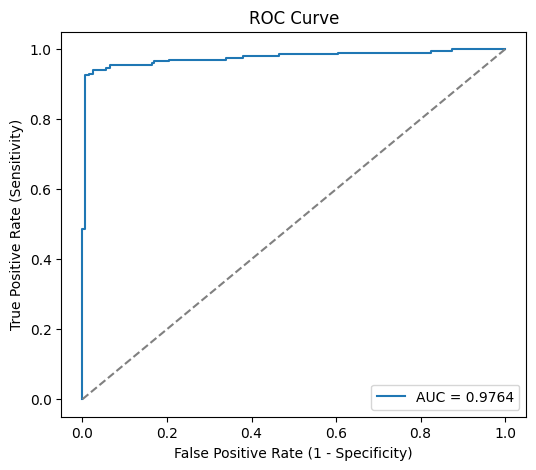

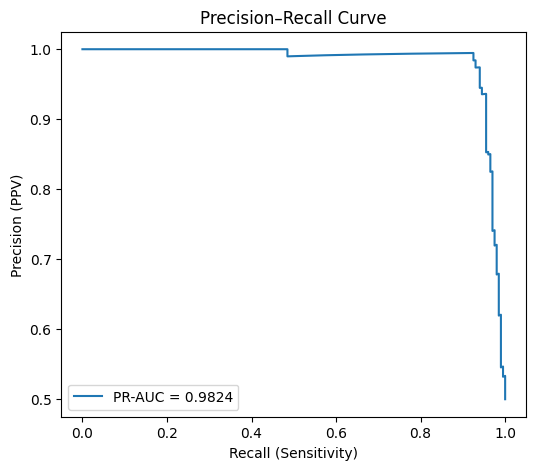

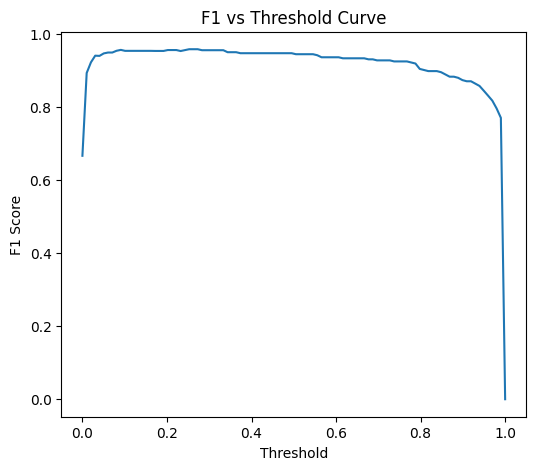

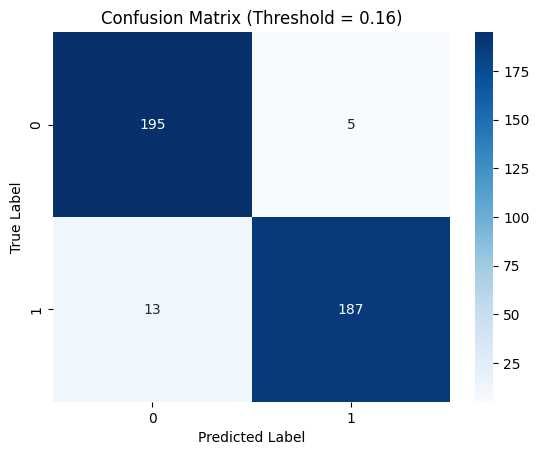

ROC-AUC: 0.9764
PR-AUC: 0.9824


In [41]:
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, f1_score, confusion_matrix,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns


# Get predictions from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class model outputs
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Find best threshold using Youden’s J statistic
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    best_thr = thr[np.argmax(youden)]
    return best_thr, y_true, y_prob


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm, 
                y_true=y_true, y_prob=y_prob)


# Plot all diagnostic curves
def plot_medical_curves(y_true, y_prob, threshold=0.5):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.legend()
    plt.show()

    # Precision–Recall Curve
    precisions, recalls, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision (PPV)")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.show()

    # F1 vs Threshold Curve
    thresholds = np.linspace(0, 1, 100)
    f1s = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    plt.figure(figsize=(6,5))
    plt.plot(thresholds, f1s)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 vs Threshold Curve")
    plt.show()

    # Confusion Matrix
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Threshold = {threshold:.2f})")
    plt.show()

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/Final_Hybrid_Model_Dynamic_Range_PTQ.tflite")
interpreter.allocate_tensors()


# Find best threshold using validation set
thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)

# Compute metrics for test set
test_metrics = metrics_at_threshold_tflite(interpreter, test_ds, thr)
print("\nTest metrics:")
for k, v in test_metrics.items():
    if k not in ["y_true", "y_prob", "cm"]:
        print(f"{k}: {v:.4f}")

# Plot all diagnostic curves for test set
plot_medical_curves(test_metrics["y_true"], test_metrics["y_prob"], threshold=thr)

float 16 bit quantization:

In [43]:
hybrid_model = tf.keras.models.load_model("/kaggle/working/Final_Hybrid_Model.keras")
converter = tf.lite.TFLiteConverter.from_keras_model(hybrid_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# Convert the model
tflite_quant_model = converter.convert()

#save model
# Save the quantized model
quantized_model_path = "/kaggle/working/Final_Hybrid_Model_F16_PTQ.tflite"
with open(quantized_model_path, "wb") as f:
    f.write(tflite_quant_model)

INFO:tensorflow:Assets written to: /tmp/tmpu544w8ve/assets


INFO:tensorflow:Assets written to: /tmp/tmpu544w8ve/assets


Saved artifact at '/tmp/tmpu544w8ve'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='hybrid_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132969965008656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132969965007120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132969965007696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132969965006352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132969965008080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132969965006544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132969965007312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132969965004432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132969965005008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132969965003664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13296996500424

W0000 00:00:1762965473.885453      48 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1762965473.885483      48 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [46]:
# compare sizes
files = [
    "/kaggle/working/Final_Hybrid_Model.keras",
    "/kaggle/working/Final_Hybrid_Model_Dynamic_Range_PTQ.tflite",
    "/kaggle/working/Final_Hybrid_Model_F16_PTQ.tflite"
]

for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"{f}: {size_mb:.2f} MB")

/kaggle/working/Final_Hybrid_Model.keras: 13.32 MB
/kaggle/working/Final_Hybrid_Model_Dynamic_Range_PTQ.tflite: 2.71 MB
/kaggle/working/Final_Hybrid_Model_F16_PTQ.tflite: 4.91 MB


In [47]:
## Evaluate float 16 bit quantized model

# dynamic range

# Function to get probabilities from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class output
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/Final_Hybrid_Model_F16_PTQ.tflite")
interpreter.allocate_tensors()


# Find best threshold (Youden’s J statistic) 
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)], y_true, y_prob


thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)


print("Validation metrics:", metrics_at_threshold_tflite(interpreter, val_ds, thr))
print("Test metrics:", metrics_at_threshold_tflite(interpreter, test_ds, thr))

Best threshold: 0.05518188
Validation metrics: {'auc': 0.9937750000000001, 'precision': 0.9948453608247423, 'recall': 0.965, 'f1': 0.9796954314720813, 'specificity': 0.995, 'cm': array([[199,   1],
       [  7, 193]])}
Test metrics: {'auc': 0.979875, 'precision': 0.949748743718593, 'recall': 0.945, 'f1': 0.9473684210526316, 'specificity': 0.95, 'cm': array([[190,  10],
       [ 11, 189]])}


Best threshold: 0.05518188

Test metrics:
auc: 0.9799
precision: 0.9497
recall: 0.9450
f1: 0.9474
specificity: 0.9500


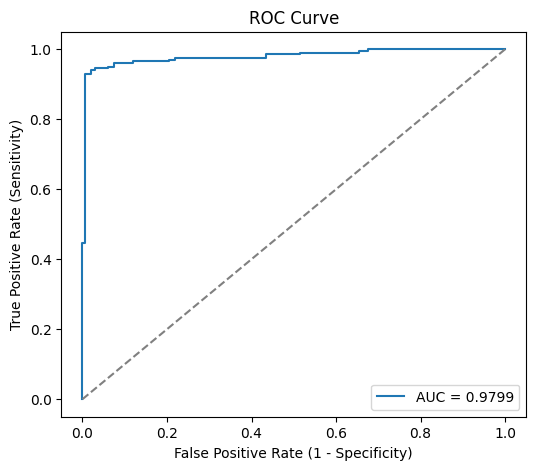

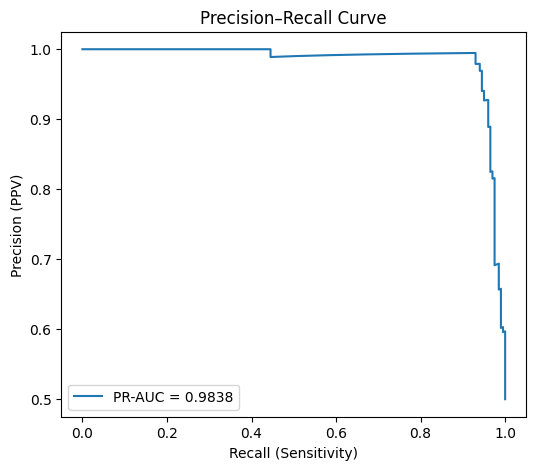

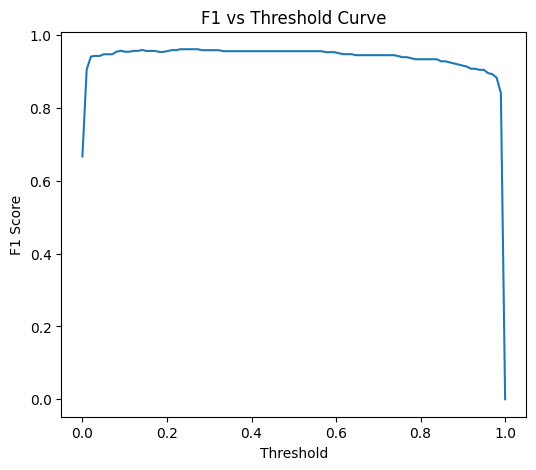

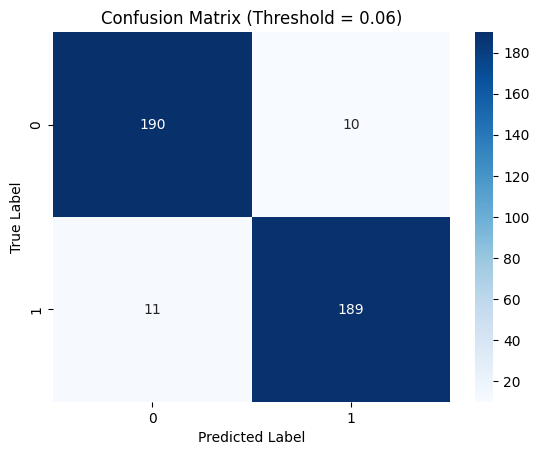

ROC-AUC: 0.9799
PR-AUC: 0.9838


In [51]:
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, f1_score, confusion_matrix,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns


# Get predictions from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class model outputs
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Find best threshold using Youden’s J statistic
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    best_thr = thr[np.argmax(youden)]
    return best_thr, y_true, y_prob


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm, 
                y_true=y_true, y_prob=y_prob)


# Plot all diagnostic curves
def plot_medical_curves(y_true, y_prob, threshold=0.5):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.legend()
    plt.show()

    # Precision–Recall Curve
    precisions, recalls, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision (PPV)")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.show()

    # F1 vs Threshold Curve
    thresholds = np.linspace(0, 1, 100)
    f1s = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    plt.figure(figsize=(6,5))
    plt.plot(thresholds, f1s)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 vs Threshold Curve")
    plt.show()

    # Confusion Matrix
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Threshold = {threshold:.2f})")
    plt.show()

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/Final_Hybrid_Model_F16_PTQ.tflite")
interpreter.allocate_tensors()


# Find best threshold using validation set
thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)

# Compute metrics for test set
test_metrics = metrics_at_threshold_tflite(interpreter, test_ds, thr)
print("\nTest metrics:")
for k, v in test_metrics.items():
    if k not in ["y_true", "y_prob", "cm"]:
        print(f"{k}: {v:.4f}")

# Plot all diagnostic curves for test set
plot_medical_curves(test_metrics["y_true"], test_metrics["y_prob"], threshold=thr)